# **Heart Disease Prediction with Machine Learning**

## Problem Definition

In this project, we build a machine learning model to predict whether a patient has heart disease based on clinical attributes such as age, blood pressure, cholesterol level, chest pain type, ECG results, and exercise-related measurements.

This is formulated as a **binary classification problem**:

- **0** → No heart disease
- **1** → Presence of heart disease


# 1) Project Overview

## 1.a Why was this problem chosen?

Heart disease is one of the leading causes of death worldwide and represents a
significant public health concern. Early detection and accurate diagnosis are
crucial for reducing mortality rates and improving patient outcomes. However,
medical diagnosis often involves analyzing multiple clinical and demographic
factors simultaneously, which makes it a suitable and meaningful application
area for machine learning techniques.

This problem was chosen because it combines real-world impact with a structured
classification task. Predicting the presence or absence of heart disease using
patient data allows machine learning models to support medical decision-making
by identifying high-risk patients early. Additionally, this dataset contains
both numerical and categorical features, making it ideal for demonstrating
data preprocessing, feature engineering, model comparison, and performance
evaluation in a supervised learning setting.



## 1.b Which machine learning techniques will be applied?

This project focuses on **supervised classification**, where the goal is to
predict a binary target variable indicating the presence (1) or absence (0) of
heart disease.

The following machine learning algorithms are applied and compared:

- **Logistic Regression**  
  Used as an interpretable baseline model that estimates the probability of
  heart disease based on a linear combination of input features.

- **Random Forest Classifier**  
  An ensemble learning method that combines multiple decision trees to capture
  complex, non-linear relationships and reduce overfitting.

- **Gradient Boosting Classifier**  
  A boosting-based ensemble method that builds models sequentially to correct
  previous errors, often achieving high predictive accuracy.

- **XGBoost (Extreme Gradient Boosting)**  
  An advanced and optimized boosting algorithm known for its strong performance
  on structured tabular data and efficient handling of complex patterns.

These models are evaluated using multiple performance metrics, and
hyper-parameter optimization is applied to improve classification performance.



## 1.c Summary information about the selected dataset

The dataset used in this project contains **2,181 patient records** with
**14 attributes**, including demographic information, clinical measurements,
and diagnostic test results.

- **Target variable:**
  - `target`  
    - 0 → No heart disease  
    - 1 → Presence of heart disease  

- **Numerical features include:**
  - age (patient age)
  - trestbps (resting blood pressure)
  - chol (serum cholesterol level)
  - thalach (maximum heart rate achieved)
  - oldpeak (ST depression)
  - ca (number of major vessels colored by fluoroscopy)

- **Categorical features include:**
  - sex
  - cp (chest pain type)
  - fbs (fasting blood sugar)
  - restecg (resting electrocardiographic results)
  - exang (exercise-induced angina)
  - slope (slope of the peak exercise ST segment)
  - thal (thalassemia)

The dataset is approximately **balanced**, with nearly equal numbers of patients
with and without heart disease. This balance allows standard classification
metrics to be used effectively without the need for resampling techniques.

Overall, the dataset is well-suited for a binary classification task and enables
a comprehensive demonstration of data preprocessing, machine learning modeling,
performance evaluation, and optimization techniques.


# **2) Exploratory Data Analysis (EDA):**


## **2.a Dataset Dimensions**

In [93]:

import numpy as np
import pandas as pd


import matplotlib.pyplot as plt
import seaborn as sns


from scipy.stats import zscore, ttest_rel


from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    GridSearchCV,
    RandomizedSearchCV
)


from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier
)


from sklearn.feature_selection import SelectKBest, f_classif, SelectFromModel
from sklearn.decomposition import PCA


from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)


from xgboost import XGBClassifier


from mlxtend.feature_selection import ExhaustiveFeatureSelector


In [166]:
# Load the heart disease dataset
df = pd.read_csv("heart_disease_raw.csv")

# Display first 5 rows as a quick check (informal, EDA starts in Section 2)
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalachh,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


the data is loaded successfully.

Here are the first rows of the data uning head() and how different they are to each other.

In [95]:
# Display last 5 rows to verify data loading
df.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalachh,exang,oldpeak,slope,ca,thal,target
2176,60,1,0,140,207,0,0,138,1,1.9,2,1,3,0
2177,46,1,0,140,311,0,1,120,1,1.8,1,2,3,0
2178,59,1,3,134,204,0,1,162,0,0.8,2,2,2,0
2179,54,1,1,154,232,0,0,164,0,0.0,2,1,2,0
2180,53,1,0,110,335,0,1,143,1,3.0,1,1,3,0


Here are the last 5 rows of the data and we can see the last raw is number 2180 with make the data 2181 lines.

In [96]:
# Clean column names
df.columns = df.columns.str.strip()

print("Columns:", df.columns.tolist())

Columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalachh', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']


this step is to ensure there is no space in the feature name so we can work on them without making a mistake.

Here is an example of a data point by using .loc and .iloc:

In [97]:
# Access a specific row by index
df.loc[30] 

age          41
sex           0
cp            1
trestbps    105
chol        198
fbs           0
restecg       1
thalachh    168
exang         0
oldpeak     0.0
slope         2
ca            1
thal          2
target        1
Name: 30, dtype: object

In [98]:
# access by integer location
df.iloc[30] 

age          41
sex           0
cp            1
trestbps    105
chol        198
fbs           0
restecg       1
thalachh    168
exang         0
oldpeak     0.0
slope         2
ca            1
thal          2
target        1
Name: 30, dtype: object

In this example, both df.loc[30] and df.iloc[30] return the same row because the DataFrame uses the default integer index (0, 1, 2, …). Since the row label (30) and the positional index (30) refer to the same entry, the outputs are identical. If the index were custom or non-integer, .loc and .iloc could return different results.


In [99]:
print("Dataset shape (rows, columns):", df.shape)
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
print("Column names:", df.columns.tolist())


Dataset shape (rows, columns): (2181, 14)
Number of rows: 2181
Number of columns: 14
Column names: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalachh', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']


## **2.b feature in the dataset means and its type**

In [100]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2181 entries, 0 to 2180
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       2181 non-null   int64  
 1   sex       2181 non-null   int64  
 2   cp        2181 non-null   int64  
 3   trestbps  2181 non-null   object 
 4   chol      2181 non-null   object 
 5   fbs       2181 non-null   object 
 6   restecg   2181 non-null   object 
 7   thalachh  2181 non-null   object 
 8   exang     2181 non-null   object 
 9   oldpeak   2181 non-null   float64
 10  slope     2181 non-null   object 
 11  ca        2181 non-null   object 
 12  thal      2181 non-null   object 
 13  target    2181 non-null   int64  
dtypes: float64(1), int64(4), object(9)
memory usage: 238.7+ KB


In [101]:
# Data types
print("Data types of each column:")
print(df.dtypes)


Data types of each column:
age           int64
sex           int64
cp            int64
trestbps     object
chol         object
fbs          object
restecg      object
thalachh     object
exang        object
oldpeak     float64
slope        object
ca           object
thal         object
target        int64
dtype: object


several columns that are supposed to be numeric clinical measurements are incorrectly interpreted as object (string) types.
This happened due to missing values were encoded as the literal string '?' instead of using proper numeric missing indicators (NaN). Any column containing even a single '?' was treated entirely as a string by Pandas.


As a result, numeric features such as trestbps, chol, thalach, and ca lost their numeric data types and appeared as object.

In [102]:
# Replace '?' with actual NaN
df.replace('?', np.nan, inplace=True)

# Convert all columns except target to numeric when possible
for col in df.columns:
    if col != "target":
        df[col] = pd.to_numeric(df[col], errors="coerce")

Replace '?' with NaN. The '?' placeholders must first be converted into meaningful missing values.


After replacing '?', we convert each feature from string to numeric.

To verify the successful transformation:

In [103]:
df.dtypes


age           int64
sex           int64
cp            int64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalachh    float64
exang       float64
oldpeak     float64
slope       float64
ca          float64
thal        float64
target        int64
dtype: object

The data are successfully float now instead of objects.

In [104]:
# Separate numeric and categorical features (excluding the target from features)
# Manually define categorical features (integer-coded categories)
categorical_features = [
    "sex",      # 0 or 1
    "cp",       # 4 chest pain types
    "fbs",      # 0 or 1
    "restecg",  # 0,1,2
    "exang",    # 0 or 1
    "slope",    # 0,1,2
    "thal"      # typically 1,2,3
]

# Numeric continuous features
numeric_features = [
    "age",
    "trestbps",
    "chol",
    "thalachh",
    "oldpeak",
    "ca"
]

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)



Numeric features: ['age', 'trestbps', 'chol', 'thalachh', 'oldpeak', 'ca']
Categorical features: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']


Although the dataset stores categorical features as integers, they represent discrete categories. Therefore, features such as sex, cp, fbs, restecg, exang, slope, ca, and thal were manually classified as categorical.

From the medical context and encoding used:

- **Numeric features** (continuous or discrete measurements):  
  `age`, `trestbps`, `chol`, `thalach`, `oldpeak`, `ca`  

- **Categorical features** (coded as integers but representing categories):  
  `sex`, `cp`, `fbs`, `restecg`, `exang`, `slope`, `thal`  

- **Target variable**:  
  `target` (binary: `1` = heart disease, `0` = no heart disease)

We will treat these groups accordingly in preprocessing and modeling.


## **2.c Descriptive statistics**

We now compute descriptive statistics for the numeric features and the target, including:

- Count, mean, standard deviation  
- Minimum and maximum values  
- 25th, 50th (median), and 75th percentiles

This helps us understand the central tendency and spread of each feature.


In [105]:
# descriptive statistics for numeric features
desc_stats = df[numeric_features + ["target"]].describe().T
desc_stats

,count,mean,std,min,25%,50%,75%,max
age,2181.0,53.477762,9.194787,28.0,46.0,54.0,60.0,77.0
trestbps,2180.0,131.679817,17.565488,92.0,120.0,130.0,140.0,200.0
chol,2158.0,247.366543,53.894818,85.0,211.0,242.0,277.0,603.0
thalachh,2180.0,148.064220,23.326238,71.0,132.0,151.0,165.0,202.0
oldpeak,2181.0,0.990509,1.141851,0.0,0.0,0.6,1.6,6.2
ca,1890.0,0.730688,1.015476,0.0,0.0,0.0,1.0,4.0
target,2181.0,0.496103,0.500099,0.0,0.0,0.0,1.0,1.0


This step shows basic descriptive statistics for the numeric features so we can understand their general range, average values, and spread.


In [106]:
iqr_table = desc_stats[["25%", "75%"]].copy()
iqr_table["IQR"] = iqr_table["75%"] - iqr_table["25%"]
iqr_table


,25%,75%,IQR
age,46.0,60.0,14.0
trestbps,120.0,140.0,20.0
chol,211.0,277.0,66.0
thalachh,132.0,165.0,33.0
oldpeak,0.0,1.6,1.6
ca,0.0,1.0,1.0
target,0.0,1.0,1.0


The table above shows, for each numeric feature, the typical range and variability.  
The additional IQR table highlights the **interquartile range (IQR)**, which is often used for outlier detection in later preprocessing steps.


In [107]:
# Descriptive stats for categorical features (value counts)
print("\nCategorical Feature Distributions")
for col in categorical_features:
    print(f"\nValue counts for {col}:")
    print(df[col].value_counts())


Categorical Feature Distributions

Value counts for sex:
sex
1    1512
0     669
Name: count, dtype: int64

Value counts for cp:
cp
0    797
2    590
1    419
3    375
Name: count, dtype: int64

Value counts for fbs:
fbs
0.0    1873
1.0     300
Name: count, dtype: int64

Value counts for restecg:
restecg
0.0    1152
1.0     864
2.0     164
Name: count, dtype: int64

Value counts for exang:
exang
0.0    1466
1.0     714
Name: count, dtype: int64

Value counts for slope:
slope
2.0    964
1.0    894
0.0    114
3.0     19
Name: count, dtype: int64

Value counts for thal:
thal
2.0    874
3.0    795
7.0    115
1.0     96
6.0     24
0.0     11
Name: count, dtype: int64


In [108]:
# Example: Filter rows where age > 70
df[df["age"] > 71]

,age,sex,cp,trestbps,chol,fbs,restecg,thalachh,exang,oldpeak,slope,ca,thal,target
129,74,0,1,120.0,269.0,0.0,0.0,121.0,1.0,0.2,2.0,1.0,2.0,1
144,76,0,2,140.0,197.0,0.0,2.0,116.0,0.0,1.1,1.0,0.0,2.0,1
238,77,1,0,125.0,304.0,0.0,0.0,162.0,1.0,0.0,2.0,3.0,2.0,0
402,76,0,2,140.0,197.0,0.0,2.0,116.0,0.0,1.1,1.0,0.0,2.0,1
463,77,1,0,125.0,304.0,0.0,0.0,162.0,1.0,0.0,2.0,3.0,2.0,0
465,77,1,0,125.0,304.0,0.0,0.0,162.0,1.0,0.0,2.0,3.0,2.0,0
616,74,0,1,120.0,269.0,0.0,0.0,121.0,1.0,0.2,2.0,1.0,2.0,1
690,77,1,0,125.0,304.0,0.0,0.0,162.0,1.0,0.0,2.0,3.0,2.0,0
838,76,0,2,140.0,197.0,0.0,2.0,116.0,0.0,1.1,1.0,0.0,2.0,1
893,74,0,1,120.0,269.0,0.0,0.0,121.0,1.0,0.2,2.0,1.0,2.0,1


This is an example to represent the data. Here are all the people who are older than 71, showing how many of them have heart disease and how many do not.

In [109]:
pd.crosstab(df["cp"], df["target"])

target,0,1
cp,,
0,588,209
1,188,231
2,205,385
3,118,257


This table shows the relationship between different chest pain types and heart disease by comparing how many patients have or do not have heart disease for each chest pain category.

target 0 = No heart disease

target 1 =  Has heart disease

## **2.d Visualizing important features**


In this section, we visualize the most important features in the dataset to better understand their relationship with the target variable (heart disease). Visualizations help reveal patterns, trends, and differences between patients with and without heart disease that may not be easily observed from numerical summaries alone. This step supports the feature analysis process and provides insight into which variables are most influential in predicting heart disease.

### **1. histogram**

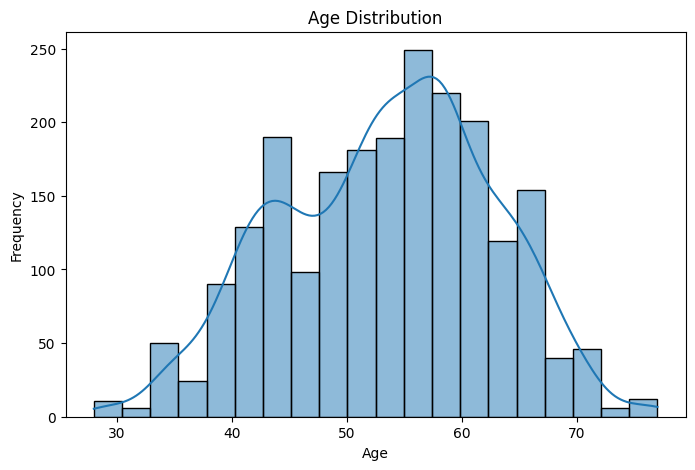

In [110]:
plt.figure(figsize=(8,5))
sns.histplot(df["age"], bins=20, kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()


The histogram shows the age distribution of patients.  
We observe that the dataset mostly includes middle-aged and older individuals, which is medically expected since heart disease risk increases with age.  
The distribution is slightly right-skewed, meaning older ages are more common in this sample.


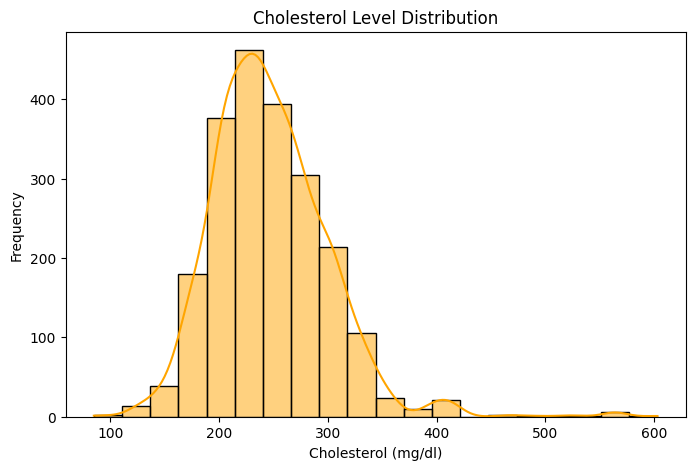

In [111]:
plt.figure(figsize=(8,5))
sns.histplot(df["chol"], kde=True, bins=20, color="orange")
plt.title("Cholesterol Level Distribution")
plt.xlabel("Cholesterol (mg/dl)")
plt.ylabel("Frequency")
plt.show()


Cholesterol values cluster around the 200–250 mg/dl range, with some higher-risk patients showing elevated levels.  
Such patterns help identify possible outliers and guide future preprocessing decisions.


### **2. Boxplot**

Boxplots help visually identify extreme values that may represent medical abnormalities or measurement errors.


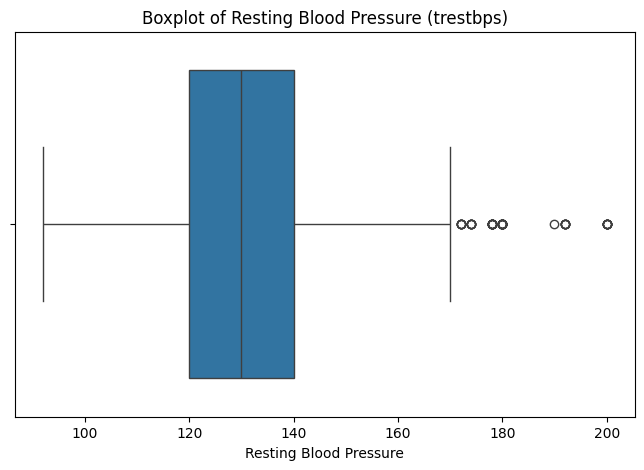

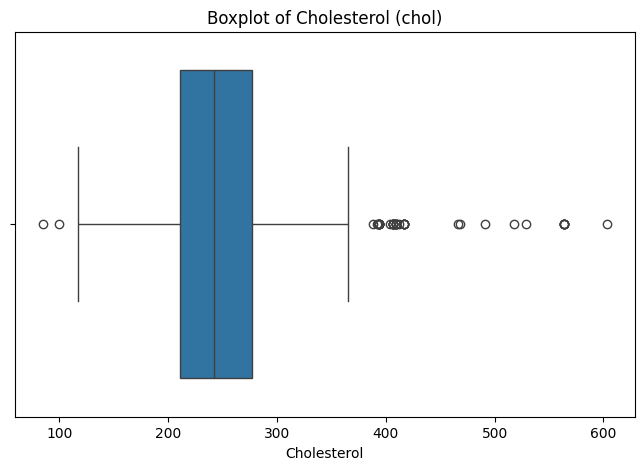

In [112]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["trestbps"])
plt.title("Boxplot of Resting Blood Pressure (trestbps)")
plt.xlabel("Resting Blood Pressure")
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(x=df["chol"])
plt.title("Boxplot of Cholesterol (chol)")
plt.xlabel("Cholesterol")
plt.show()



The boxplot reveals variability in blood pressure and highlights potential outliers.  
Elevated resting blood pressure is a known risk factor for cardiovascular diseases; thus, understanding its distribution is crucial for modeling.


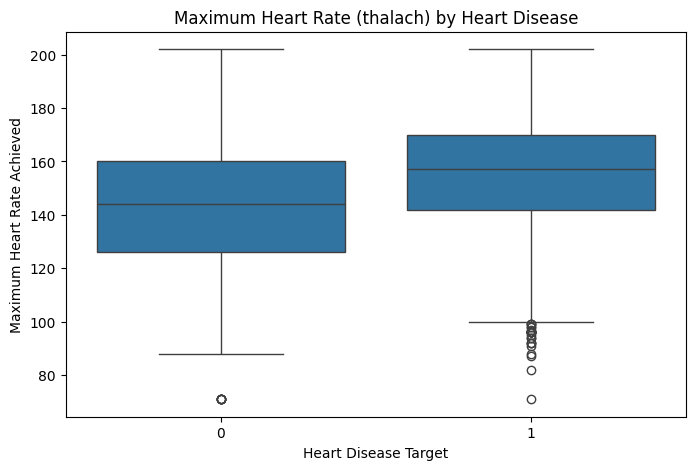

In [113]:
plt.figure(figsize=(8,5))
sns.boxplot(x="target", y="thalachh", data=df)
plt.title("Maximum Heart Rate (thalach) by Heart Disease")
plt.xlabel("Heart Disease Target")
plt.ylabel("Maximum Heart Rate Achieved")
plt.show()


Patients without heart disease tend to reach higher maximum heart rates during exercise.  
This aligns with medical expectations, lower stress tolerance is associated with cardiovascular problems.


### **3. countplot**

We visualize how categorical medical indicators differ across disease vs non-disease patients.

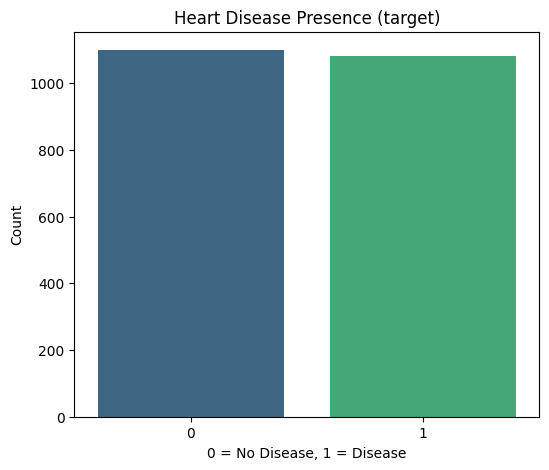

In [114]:
plt.figure(figsize=(6,5))
sns.countplot(
    x="target",
    hue="target",
    data=df,
    palette="viridis",
    legend=False
)
plt.title("Heart Disease Presence (target)")
plt.xlabel("0 = No Disease, 1 = Disease")
plt.ylabel("Count")
plt.show()


This countplot shows the number of patients with and without heart disease. The two classes are almost equal in size, indicating that the dataset is well balanced.


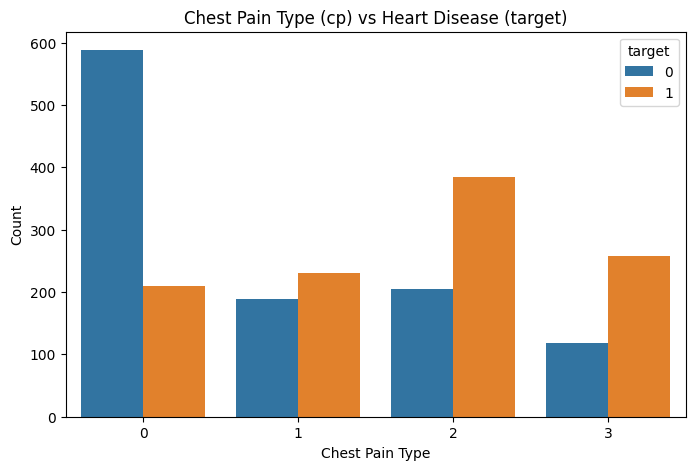

In [115]:
plt.figure(figsize=(8,5))
sns.countplot(x="cp", hue="target", data=df)
plt.title("Chest Pain Type (cp) vs Heart Disease (target)")
plt.xlabel("Chest Pain Type")
plt.ylabel("Count")
plt.show()


Certain chest pain categories appear much more frequently among patients with heart disease.  
This confirms that `cp` is a highly predictive feature and will likely be important for boosting models.


### **4. Scatterplot**

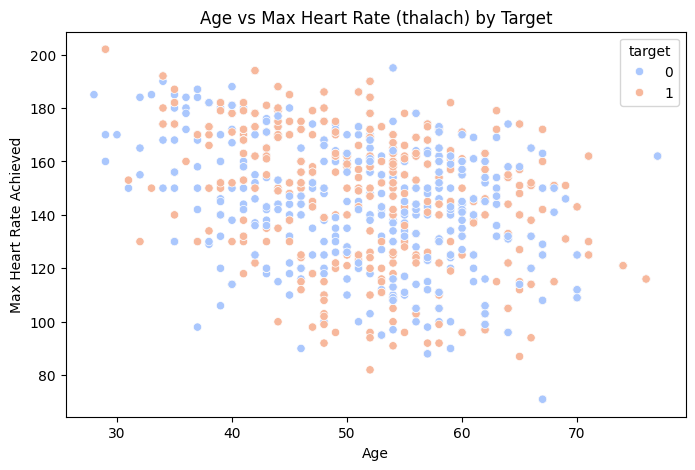

In [116]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="age", y="thalachh", hue="target", data=df, palette="coolwarm")
plt.title("Age vs Max Heart Rate (thalach) by Target")
plt.xlabel("Age")
plt.ylabel("Max Heart Rate Achieved")
plt.show()


This scatterplot shows the relationship between age and maximum heart rate. The two target classes overlap across the plot, indicating that these features alone do not clearly separate patients with and without heart disease.

So, we will try another feature to see if we can observe a pattern.

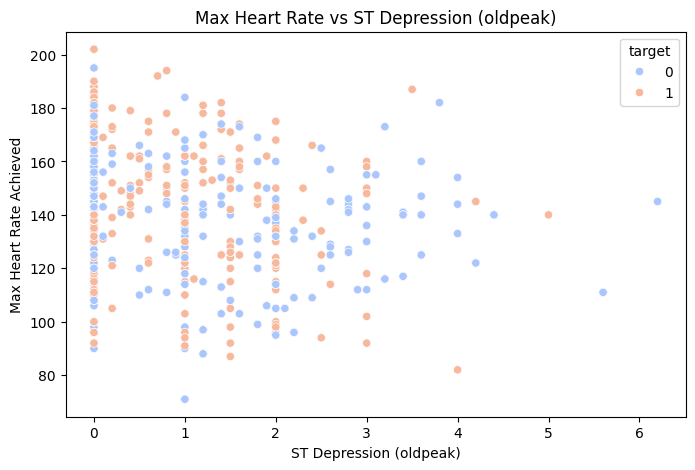

In [117]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x="oldpeak",
    y="thalachh",
    hue="target",
    data=df,
    palette="coolwarm"
)
plt.title("Max Heart Rate vs ST Depression (oldpeak)")
plt.xlabel("ST Depression (oldpeak)")
plt.ylabel("Max Heart Rate Achieved")
plt.show()


This plot shows that higher ST depression values are more common among patients with heart disease, while maximum heart rate generally decreases as ST depression increases.


### **5. Heatmap**

We compute the correlations between numerical variables to identify patterns such as:
- features strongly associated with heart disease  
- relationships between physiological measurements  

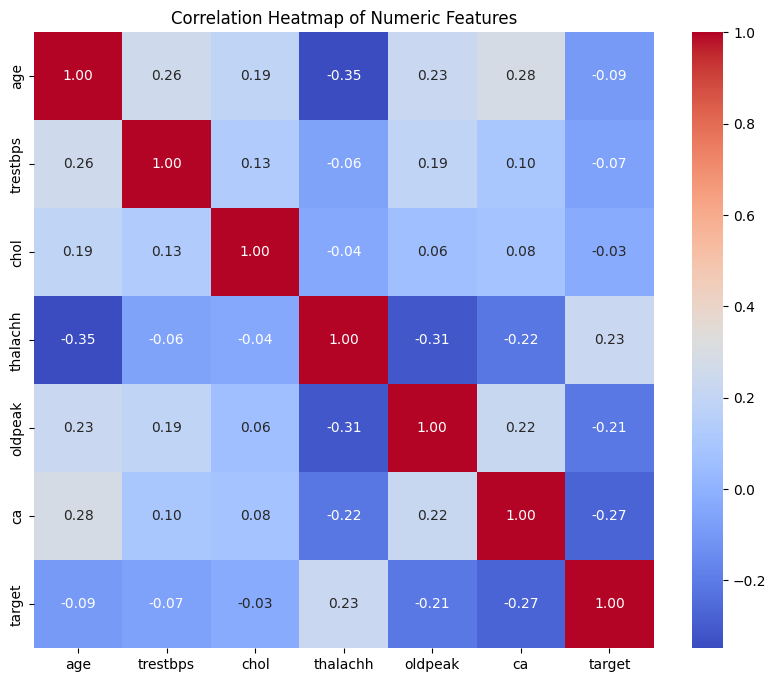

In [118]:
plt.figure(figsize=(10,8))
sns.heatmap(df[numeric_features + ["target"]].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numeric Features")
plt.show()


The heatmap reveals relationships between clinical measurements.  
Notably:
- `thalach` (max heart rate) is **negatively correlated** with heart disease  
- `oldpeak` shows **positive correlation**, as expected

These insights help in feature selection and model interpretation.


### **6.Pairplot of Key Features**

A pairplot visualizes pairwise relationships between features and highlights class separation patterns.
Due to computational cost, we include a subset of highly relevant features.


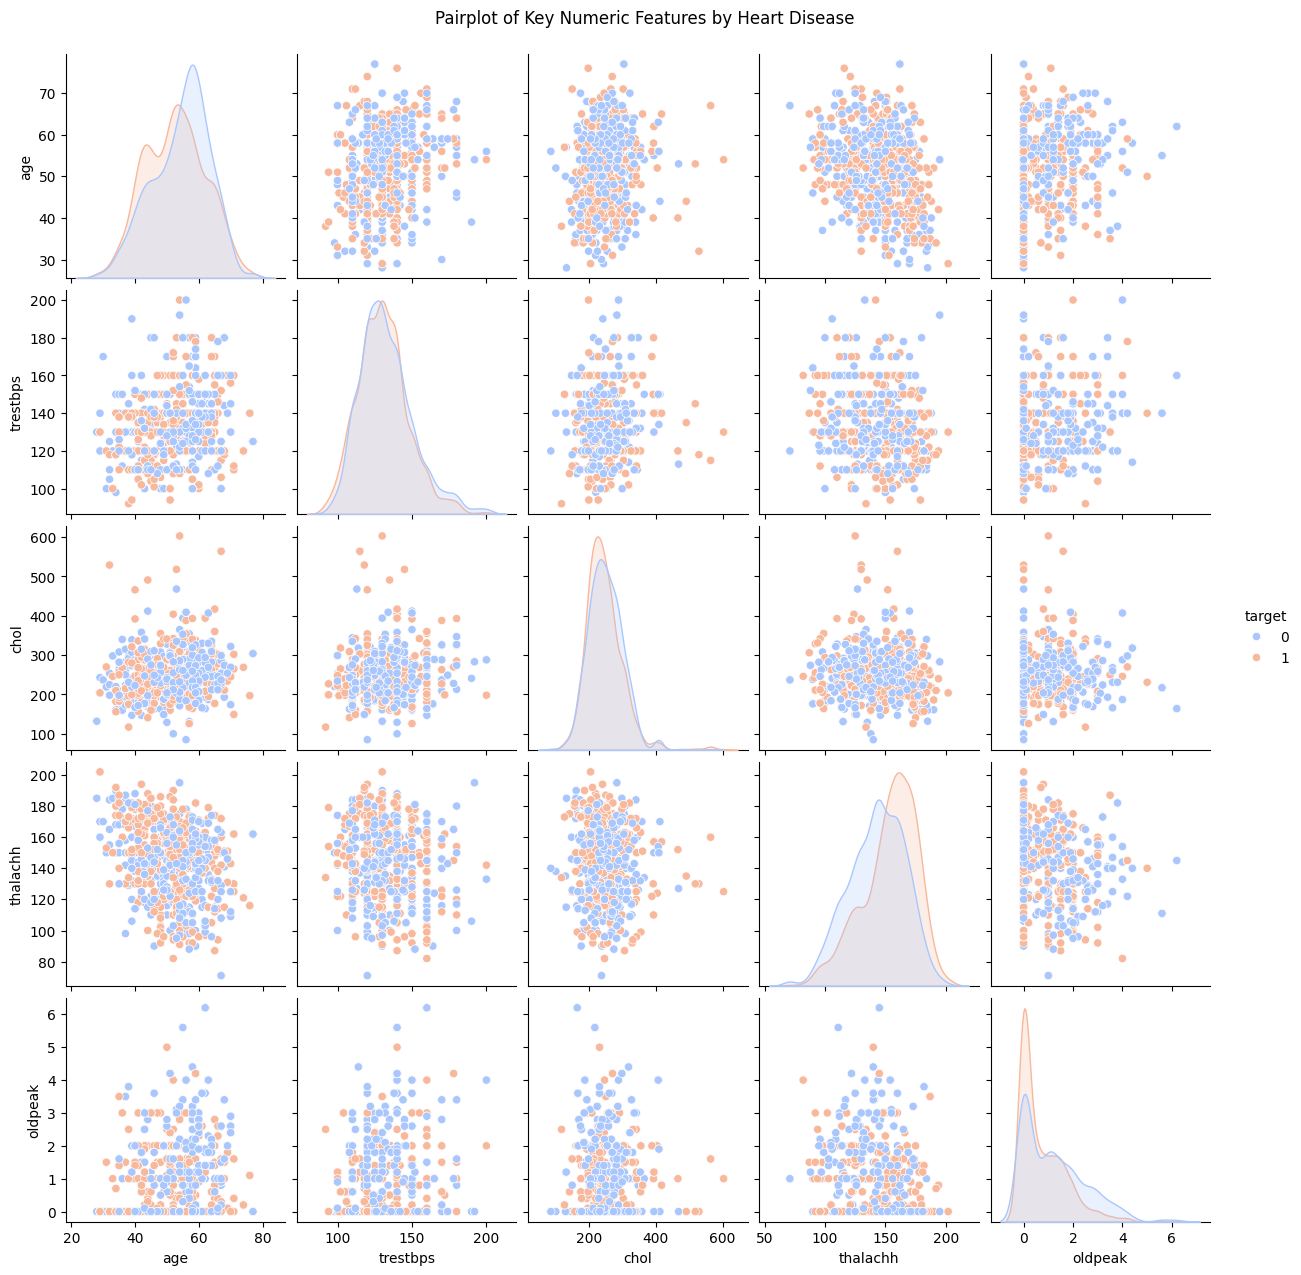

In [119]:
selected_cols = ["age", "trestbps", "chol", "thalachh", "oldpeak", "target"]

sns.pairplot(df[selected_cols], hue="target", diag_kind="kde", palette="coolwarm")
plt.suptitle("Pairplot of Key Numeric Features by Heart Disease", y=1.02)
plt.show()


This pairplot visualizes joint relationships between multiple numeric features such as age, blood pressure, cholesterol, maximum heart rate and ST depression(oldpeak).

Distinct patterns appear between patients with and without heart disease:

- Patients with heart disease generally have **lower maximum heart rate (thalach)**.  
- **Oldpeak** values are visibly higher among heart disease cases.  
- Certain feature combinations (e.g., `chol` vs `age`, `thalach` vs `oldpeak`) form separable clusters, indicating good predictive potential.

This gives a multi-dimensional view of the dataset and highlights meaningful feature interactions.


### **7. Violinplot**

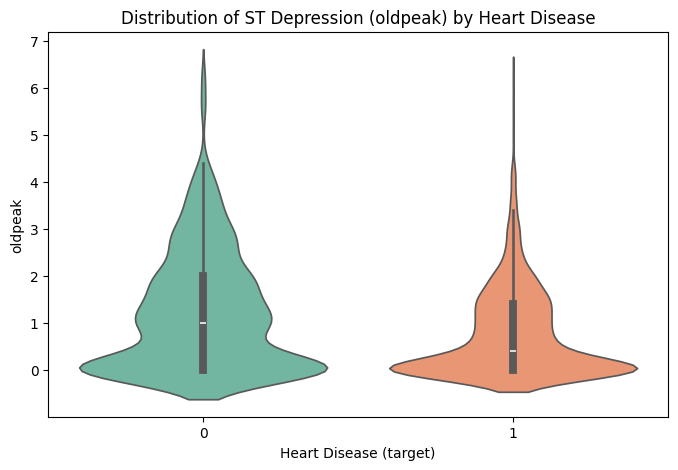

In [120]:
plt.figure(figsize=(8,5))
sns.violinplot(
    x="target",
    y="oldpeak",
    hue="target",
    data=df,
    palette="Set2",
    legend=False
)
plt.title("Distribution of ST Depression (oldpeak) by Heart Disease")
plt.xlabel("Heart Disease (target)")
plt.ylabel("oldpeak")
plt.show()


This violin plot shows the distribution of ST depression for patients with and without heart disease. The heart disease group (1) has a tighter distribution, while the non-disease group (0) shows a wider spread, indicating more variability in oldpeak values.


### **EDA Summary**

- The dataset contains clinical measurements and categorical medical indicators relevant to heart disease.  
- Numeric features show clear spread and potential outliers, especially in blood pressure and cholesterol.  
- Several categorical features such as chest pain type, fasting blood sugar, and ECG results show strong differences between patients with and without heart disease.  
- Visualizations demonstrate medically consistent patterns:
  - Lower maximum heart rate is associated with higher heart disease risk.
  - Certain chest pain types are strongly linked with positive diagnosis.
  - ST depression (`oldpeak`) and resting heart behavior show notable relationships.
- Correlation analysis confirms which features contribute most to predicting the target variable.



# 3) Data Preprocessing

In this section, we prepare the dataset for machine learning by performing:

1. Missing value analysis  
2. Handling missing values
3. Outlier detection using (two different methods)
4. Outlier handling  
5. Scaling (normalization) of numeric features  
6. Encoding of categorical features  

These steps are essential to ensure that the machine learning algorithms perform correctly and consistently.


## 3.a Missing Values Analysis

We begin by checking whether the dataset contains any missing (NaN) values.  
Missing values can disrupt model training and may require imputation or removal depending on their pattern.


In [121]:
# Count missing values
missing_counts = df.isnull().sum()

# Percentage missing
missing_percent = (missing_counts / len(df)) * 100

missing_data = pd.DataFrame({
    "Missing Count": missing_counts,
    "Missing Percent (%)": missing_percent
})

missing_data


,Missing Count,Missing Percent (%)
age,0,0.000000
sex,0,0.000000
cp,0,0.000000
trestbps,1,0.045851
chol,23,1.054562
fbs,8,0.366804
restecg,1,0.045851
thalachh,1,0.045851
exang,1,0.045851
oldpeak,0,0.000000


## 3.b Handling Missing Values

The missing values in this dataset are not uniformly distributed.  
Most features have very few missing entries, but some clinical variables such as **cholesterol (chol)**, **slope**, **ca**, and **thal** have a noticeable amount of missingness.

To avoid losing data by dropping rows, we apply **imputation**:

- For **numeric clinical measurements** (`trestbps`, `chol`, `thalach`, `ca`),  
  we compare **mean** vs **median** imputation. Because these variables are often skewed and may contain outliers, median imputation is usually more robust and better preserves the original distribution.


- For **categorical / binary features** (`fbs`, `restecg`, `exang`, `slope`, `thal`),  
  we use the **mode** (most frequent category), which is a natural and interpretable choice.

First, we visualize how mean vs median imputation affect the distribution of `chol` to justify the choice.


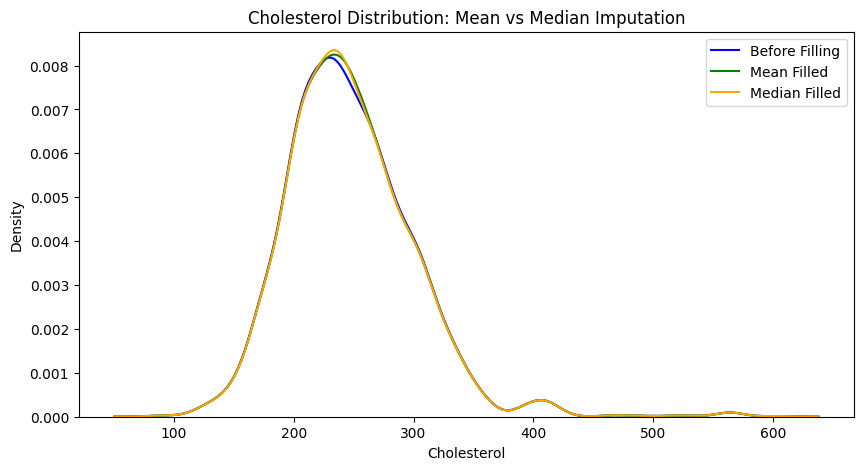

In [122]:
# Ensure chol is numeric
df['chol'] = pd.to_numeric(df['chol'], errors='coerce')

# Backup original cholesterol values
chol_before = df['chol'].copy()

# Mean imputation (for comparison only)
df_mean = df.copy()
df_mean['chol'] = df_mean['chol'].fillna(df_mean['chol'].mean())

# Median imputation (for comparison only)
df_median = df.copy()
df_median['chol'] = df_median['chol'].fillna(df_median['chol'].median())

# Plot KDE comparison
plt.figure(figsize=(10, 5))
sns.kdeplot(chol_before.dropna(), label="Before Filling", color="blue")
sns.kdeplot(df_mean['chol'], label="Mean Filled", color="green")
sns.kdeplot(df_median['chol'], label="Median Filled", color="orange")
plt.title("Cholesterol Distribution: Mean vs Median Imputation")
plt.xlabel("Cholesterol")
plt.legend()
plt.show()



From the KDE plot, we observe that:

- **Mean imputation** pulls the distribution toward the center and reduces the spread.
- **Median imputation** keeps the right-skewed shape of cholesterol values much closer to the original distribution.

Since medical measurements like cholesterol are not normally distributed and can contain extreme values,  
**median imputation is more robust and better reflects the true population**.

Therefore, in the final preprocessing pipeline, we use:
- **Median imputation** for numeric clinical features.
- **Mode imputation** for categorical/binary features.


Now apply final imputations:

In [123]:
# Numeric features we will treat as continuous
numeric_features = ["age", "trestbps", "chol", "thalachh", "oldpeak", "ca"]

# Categorical/binary features
categorical_features = ["sex", "cp", "fbs", "restecg", "exang", "slope", "thal"]

# Convert numeric-like columns to numeric (if not already)
for col in numeric_features:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Median imputation for numeric features with missing values
num_impute_cols = ["trestbps", "chol", "thalachh", "ca"]
for col in num_impute_cols:
    df[col] = df[col].fillna(df[col].median())

# Mode imputation for categorical/binary features with missing values
cat_impute_cols = ["fbs", "restecg", "exang", "slope", "thal"]
for col in cat_impute_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Check that all missing values are handled
df.isnull().sum()



age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalachh    0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

checking the missing values after ahndling them

In [124]:
# Count missing values
missing_counts = df.isnull().sum()

# Percentage missing
missing_percent = (missing_counts / len(df)) * 100

missing_data = pd.DataFrame({
    "Missing Count": missing_counts,
    "Missing Percent (%)": missing_percent
})

missing_data


,Missing Count,Missing Percent (%)
age,0,0.0
sex,0,0.0
cp,0,0.0
trestbps,0,0.0
chol,0,0.0
fbs,0,0.0
restecg,0,0.0
thalachh,0,0.0
exang,0,0.0
oldpeak,0,0.0


## 3.c Outlier Detection

Outliers in clinical data may correspond to:
- true extreme medical conditions, or  
- measurement / recording errors.

Both cases can strongly influence some machine learning algorithms, so it is important to detect them.

We apply two complementary outlier detection methods on the numeric features:

1. **IQR (Interquartile Range) Method**  
   - Uses the 25th percentile (Q1) and 75th percentile (Q3).  
   - Values below `Q1 - 1.5 × IQR` or above `Q3 + 1.5 × IQR` are flagged as outliers.  
   - Robust to skewed distributions.

2. **Z-Score Method**  
   - Standardizes each feature and flags values with `|z| > 3` as outliers.  
   - More appropriate when the feature is approximately normally distributed.


The IQR and Z-score methods were selected to detect outliers because they are two widely used and complementary approaches. 

The Z-score method measures how far a value is from the mean in terms of standard deviations and works well for approximately normally distributed data.

In [125]:
# IQR-based outlier count
def iqr_outlier_count(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return ((series < lower) | (series > upper)).sum()

iqr_counts = {col: iqr_outlier_count(df[col]) for col in numeric_features}
iqr_df = pd.DataFrame.from_dict(iqr_counts, orient="index", columns=["IQR Outlier Count"])
iqr_df



,IQR Outlier Count
age,0
trestbps,65
chol,45
thalachh,8
oldpeak,31
ca,155


In [126]:
# Z-score-based outlier count
z_counts = {}
for col in numeric_features:
    z_scores = zscore(df[col])
    z_counts[col] = (abs(z_scores) > 3).sum()

z_df = pd.DataFrame.from_dict(z_counts, orient="index", columns=["Z-Score Outlier Count"])

z_df

,Z-Score Outlier Count
age,0
trestbps,15
chol,26
thalachh,7
oldpeak,14
ca,28


The IQR method typically flags more outliers than the Z-score method, especially for skewed variables such as:

- `trestbps` (resting blood pressure)
- `chol` (cholesterol)
- `oldpeak` (ST depression)
- `ca` (number of major vessels)

The Z-score method assumes an approximately normal distribution, which is not always valid for medical features.  
Therefore, we rely primarily on the **IQR method** to guide outlier handling, while using Z-scores as a secondary check.


## 3.d Outlier Handling

Completely removing all rows that contain outliers could discard informative and clinically important cases, and would reduce the dataset size.

Instead of deleting those patients, we apply a **capping (winsorization)** strategy:

- Values below the **1st percentile** are set to the 1st percentile.
- Values above the **99th percentile** are set to the 99th percentile.

This approach:
- Keeps all patients in the dataset.
- Reduces the influence of extreme values on algorithms sensitive to scale.
- Preserves the overall shape and ranking of the data while controlling the tails.


In [127]:
def cap_outliers(df, feature, lower_q=0.01, upper_q=0.99):
    lower = df[feature].quantile(lower_q)
    upper = df[feature].quantile(upper_q)
    df[feature] = df[feature].clip(lower=lower, upper=upper)

# Apply capping to all numeric features
for col in numeric_features:
    cap_outliers(df, col)

# Quick sanity check: describe again
df[numeric_features].describe().T


,count,mean,std,min,25%,50%,75%,max
age,2181.0,53.471802,9.032650,34.0,46.0,54.0,60.0,71.0
trestbps,2181.0,131.608436,17.116058,100.0,120.0,130.0,140.0,180.0
chol,2181.0,246.757909,49.927104,147.0,211.0,242.0,276.0,409.0
thalachh,2181.0,148.110041,22.974293,92.0,132.0,151.0,165.0,192.0
oldpeak,2181.0,0.979688,1.102963,0.0,0.0,0.6,1.6,4.2
ca,2181.0,0.633196,0.977395,0.0,0.0,0.0,1.0,4.0


## 3.e Feature Scaling (Normalization)

The numeric features in this dataset are measured on very different scales:

- `age` (years)
- `trestbps` (mm Hg)
- `chol` (mg/dl)
- `thalach` (beats per minute)
- `oldpeak` (ST depression)
- `ca` (0–4 vessels)

If we use algorithms that rely on distances or gradients, features with larger numeric ranges can dominate the learning process.

To avoid this, we apply **standardization** using `StandardScaler`, which transforms each numeric feature as:

$$
z = \frac{x - \mu}{\sigma}
$$


After scaling, all numeric features have:
- Mean ≈ 0
- Standard deviation ≈ 1

This makes the optimization process more stable and allows fair comparison between different algorithms.


In [128]:
scaler = StandardScaler()
scaled_numeric = scaler.fit_transform(df[numeric_features])

# quick look at the first 5 rows
scaled_numeric[:5]


array([[ 1.05510377,  0.78257706, -0.27562313,  0.08228293,  1.19733341,
        -0.64798871],
       [-1.82400283, -0.09399392,  0.06495138,  1.69314793,  2.28556129,
        -0.64798871],
       [-1.38106335, -0.09399392, -0.85660316,  1.04009455,  0.3811625 ,
        -0.64798871],
       [ 0.27995968, -0.67837457, -0.21552174,  1.3013159 , -0.16295144,
        -0.64798871],
       [ 0.39069455, -0.67837457,  2.148466  ,  0.64826252, -0.34432275,
        -0.64798871]])

**The transformed numeric features now have:**

- A mean of approximately **0**
- A standard deviation of **1**

For example, the first scaled row: [ 1.1, 0.8, -0.3, 0.1, 1.2, -0.6]

can be interpreted as:

- Age is 1.1 standard deviations above the mean

- Resting blood pressure is 0.8 standard deviations above its mean

- Maximum heart rate (thalachh) is 0.3 standard deviations below the mean

- ST depression (oldpeak) is 0.1 standard deviations above the mean

- Number of vessels (ca) is 1.2 standard deviations above the mean

- Cholesterol is 0.6 standard deviations below the mean

Standardization is important because:

- Logistic Regression and SVM require features on similar scales  
- Gradient Boosting and Random Forest are less sensitive, but consistent preprocessing ensures fair comparison  
- It improves model convergence and numerical stability  




## 3.f Encoding Categorical Features

Several features in the heart disease dataset are categorical by nature, even though they are stored as integers:

- `sex` – biological sex (0 = female, 1 = male)
- `cp` – chest pain type (0–3)
- `fbs` – fasting blood sugar (>120 mg/dl) (0/1)
- `restecg` – resting electrocardiographic results
- `exang` – exercise-induced angina (0/1)
- `slope` – slope of the ST segment (0–2)
- `thal` – thalassemia status (1–3)

Treating these as ordinary numeric values would incorrectly impose an ordering and distance  

To correctly represent these variables for machine learning algorithms, we use **One-Hot Encoding**:

- Each category becomes a separate binary feature.
- We use `drop="first"` to avoid perfect multicollinearity (dummy variable trap).
- `handle_unknown="ignore"` allows the model to safely handle unseen categories during testing.


In [129]:
# Reuse numeric_features and categorical_features defined earlier

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features)
    ]
)

preprocessor


,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,copy,True
,with_mean,True
,with_std,True


# 4) Machine Learning Algorithms

In this section, several supervised machine learning algorithms are applied to the heart disease dataset to classify patients as either having heart disease (1) or not (0). The models are trained on preprocessed data (missing-value imputation, outlier-aware scaling, and one-hot encoding) and then evaluated using various performance metrics. Both baseline models and hyperparameter-optimized versions are compared.


## 4a. Selected Machine Learning Algorithms

In this project, the goal is to **predict the presence of heart disease** (1 = disease, 0 = no disease) based on clinical and demographic features such as age, cholesterol, resting blood pressure, maximum heart rate, and exercise-induced angina. This is a **binary classification** problem with mostly tabular, mixed-type data (numeric + categorical).

To capture different types of decision boundaries and compare their strengths, we used **four supervised learning algorithms** from different families:

1. **Logistic Regression (LR)** – linear baseline, interpretable
2. **Random Forest Classifier (RF)** – ensemble of decision trees (bagging)
3. **Gradient Boosting Classifier (GB)** – boosting-based ensemble
4. **XGBoost Classifier (XGB)** – optimized gradient boosting implementation

These models were selected because:

- They are **widely used in medical decision support systems**.
- They can handle **mixed input features** after encoding and scaling steps.
- They offer a good balance between **interpretability, non-linearity, and performance**.

### Logistic Regression

Logistic Regression is a **linear classification model** that estimates the probability of heart disease using a logistic (sigmoid) function. It assumes a linear relationship between the features and the log-odds of the target.

- It is a **strong baseline** and easy to interpret.
- The learned coefficients show **how each feature increases or decreases the risk** of heart disease.
- However, it cannot naturally capture complex **non-linear relationships** without manual feature engineering.

### Random Forest

Random Forest is an **ensemble of many decision trees** trained on different bootstrap samples and feature subsets. Each tree makes a prediction, and the forest combines them (majority vote).

- It can model **non-linear interactions** between features.
- It is **robust to noise and outliers** and handles mixed data quite well.
- It also provides **feature importance**, which helps interpret which variables are most important for predicting heart disease.
- The main drawback is that it behaves more like a **black box** compared to Logistic Regression.

### Gradient Boosting

Gradient Boosting builds trees **sequentially**. Each new tree tries to correct the errors of the previous ensemble by focusing on difficult examples.

- It usually achieves **higher accuracy** than a single tree or simple models.
- It is capable of modeling complex **non-linear patterns**.
- However, it is **more sensitive to hyperparameters** (learning rate, number of trees, depth) and can overfit if not tuned carefully.

### XGBoost

XGBoost (Extreme Gradient Boosting) is a **highly optimized implementation** of gradient boosting with regularization, clever tree growth, and hardware optimizations.

- Often achieves **state-of-the-art performance** on structured/tabular data.
- Includes **regularization** to control model complexity and reduce overfitting.
- Supports **parallelization** and is relatively fast even with many trees.
- The main disadvantages are:
  - It has **many hyperparameters**, which makes tuning more complex.
  - Model interpretation is more difficult than with Logistic Regression.

By comparing these four algorithms, I can evaluate:
- How much improvement non-linear and boosting methods provide over a simple linear model.
- Whether more complex models (Random Forest, Gradient Boosting, XGBoost) significantly improve predictive performance for heart disease detection.


## 4.b Advantages and Disadvantages of the Selected Methods

### Logistic Regression (LR)

**Advantages**
- Very **interpretable**: coefficients indicate how each feature affects the log-odds of heart disease.
- **Fast** to train and easy to implement.
- Works well when the relationship between features and target is approximately **linear**.
- Outputs **probabilities**, which are useful for medical decision-making.

**Disadvantages**
- Limited ability to model **non-linear** relationships.
- Performance can be suboptimal on complex, high-dimensional data.
- Sensitive to **multicollinearity** and requires properly scaled/encoded features.

---

### Random Forest (RF)

**Advantages**
- Captures **non-linear patterns** and complex interactions.
- Naturally handles **mixed features** (numeric + categorical after encoding).
- More **robust to outliers** due to averaging across trees.
- Provides **feature importance**, which helps interpret which variables are most relevant.

**Disadvantages**
- More **computationally expensive** than Logistic Regression.
- The final model behaves more like a **black box**: individual decisions are harder to explain.
- With many deep trees, model size can become large.

---

### Gradient Boosting (GB)

**Advantages**
- Often achieves **high accuracy** by correcting errors step by step.
- Can model **complex decision boundaries**.
- Supports various loss functions and regularization options.

**Disadvantages**
- **Training is slower** than Random Forest because trees are built sequentially.
- **Sensitive to hyperparameters** (learning rate, number of estimators, depth, subsample).
- Can **overfit** if learning rate is too high or trees are too deep.

---

### XGBoost (XGB)

**Advantages**
- Usually one of the **best-performing algorithms** on tabular data.
- Includes **built-in regularization** (L1/L2), which helps prevent overfitting.
- Efficient implementation with **parallelization** and handling of missing values.
- Provides **feature importance** and advanced options such as early stopping.

**Disadvantages**
- Many hyperparameters → **tuning is more complex** and time-consuming.
- Less interpretable than Logistic Regression.
- Slightly more complex to set up (additional library installation).


## 4.c Evaluation Metrics

To evaluate the performance of the models on heart disease prediction, I used several standard classification metrics:

- **Accuracy**
- **Precision**
- **Recall (Sensitivity)**
- **F1-Score**
- **ROC-AUC (Area Under the ROC Curve)**

Let:

- TP = True Positives (disease correctly predicted as 1)
- TN = True Negatives (no disease correctly predicted as 0)
- FP = False Positives (no disease predicted as 1)
- FN = False Negatives (disease predicted as 0)

### Accuracy

The proportion of correctly classified samples:

$$
\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}
$$

### Precision (for the positive class: heart disease)

Out of all patients predicted as “disease = 1”, how many actually have the disease?

$$
\text{Precision} = \frac{TP}{TP + FP}
$$

### Recall (Sensitivity)

Out of all patients who truly have heart disease, how many did the model correctly detect?

$$
\text{Recall} = \frac{TP}{TP + FN}
$$

This is very important in medical problems, because **missing a positive case (FN)** can be costly.

### F1-Score

The harmonic mean of Precision and Recall:

$$
\text{F1} = 2 \times \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}
$$

F1 is useful when we want a **balance between Precision and Recall**, especially when both FP and FN are important.

### ROC-AUC

- The **ROC curve** plots the True Positive Rate (Recall) vs. the False Positive Rate (FP / (FP + TN)) at different classification thresholds.
- **AUC (Area Under the Curve)** summarizes the model’s ability to separate positive and negative classes:
  - AUC ≈ 0.5 → random guessing
  - AUC close to 1.0 → excellent discrimination

In this project, I primarily focus on:
- **F1-score and Recall** for medical relevance
- **ROC-AUC** for global discrimination ability
- **Accuracy** as a general performance indicator


## 4.d Implementation of the Selected Methods


In [131]:
# Define features and target
X = df.drop("target", axis=1)
y = df["target"]


In [132]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape


((1744, 13), (437, 13))

In [133]:
def evaluate_model(name, model, X_train, y_train, X_test, y_test, verbose=True):
    """
    Train model, evaluate on test set, and return metrics as a dict.
    """
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
        roc = roc_auc_score(y_test, y_proba)
    else:
        roc = np.nan

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)

    if verbose:
        print(f"\n=== {name} ===")
        print(f"Accuracy : {acc:.4f}")
        print(f"Precision: {prec:.4f}")
        print(f"Recall   : {rec:.4f}")
        print(f"F1-score : {f1:.4f}")
        if not np.isnan(roc):
            print(f"ROC-AUC  : {roc:.4f}")
        print("\nClassification report:\n", classification_report(y_test, y_pred))

    return {
        "model": name,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "roc_auc": roc
    }


### Logistic Regression (LR)

In [134]:
log_reg = LogisticRegression(
    penalty="l2",
    C=1.0,
    solver="liblinear",
    max_iter=1000,
    random_state=42
)

lr_results = evaluate_model(
    "Logistic Regression (baseline)",
    log_reg,
    X_train, y_train, X_test, y_test
)



=== Logistic Regression (baseline) ===
Accuracy : 0.6911
Precision: 0.6752
Recall   : 0.7281
F1-score : 0.7007
ROC-AUC  : 0.7443

Classification report:
               precision    recall  f1-score   support

           0       0.71      0.65      0.68       220
           1       0.68      0.73      0.70       217

    accuracy                           0.69       437
   macro avg       0.69      0.69      0.69       437
weighted avg       0.69      0.69      0.69       437



### Random Forest (RF)

In [135]:
rf_clf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_results = evaluate_model(
    "Random Forest (baseline)",
    rf_clf,
    X_train, y_train, X_test, y_test
)



=== Random Forest (baseline) ===
Accuracy : 0.9085
Precision: 0.8865
Recall   : 0.9355
F1-score : 0.9103
ROC-AUC  : 0.9809

Classification report:
               precision    recall  f1-score   support

           0       0.93      0.88      0.91       220
           1       0.89      0.94      0.91       217

    accuracy                           0.91       437
   macro avg       0.91      0.91      0.91       437
weighted avg       0.91      0.91      0.91       437



### Gradient Boosting (GB)

In [136]:
gb_clf = GradientBoostingClassifier(
    random_state=42
)

gb_results = evaluate_model(
    "Gradient Boosting (baseline)",
    gb_clf,
    X_train, y_train, X_test, y_test
)



=== Gradient Boosting (baseline) ===
Accuracy : 0.8307
Precision: 0.8122
Recall   : 0.8571
F1-score : 0.8341
ROC-AUC  : 0.9132

Classification report:
               precision    recall  f1-score   support

           0       0.85      0.80      0.83       220
           1       0.81      0.86      0.83       217

    accuracy                           0.83       437
   macro avg       0.83      0.83      0.83       437
weighted avg       0.83      0.83      0.83       437



### XGBoost (XGB)

In [137]:
xgb_clf = XGBClassifier(
    random_state=42,
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    n_jobs=-1
)

xgb_results = evaluate_model(
    "XGBoost (baseline)",
    xgb_clf,
    X_train, y_train, X_test, y_test
)



=== XGBoost (baseline) ===
Accuracy : 0.8101
Precision: 0.7965
Recall   : 0.8295
F1-score : 0.8126
ROC-AUC  : 0.9004

Classification report:
               precision    recall  f1-score   support

           0       0.82      0.79      0.81       220
           1       0.80      0.83      0.81       217

    accuracy                           0.81       437
   macro avg       0.81      0.81      0.81       437
weighted avg       0.81      0.81      0.81       437



In [138]:
baseline_results = [
    lr_results,
    rf_results,
    gb_results,
    xgb_results
]

baseline_df = pd.DataFrame(baseline_results)
baseline_df


,model,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression (baseline),0.691076,0.675214,0.728111,0.700665,0.744302
1,Random Forest (baseline),0.908467,0.886463,0.935484,0.910314,0.980949
2,Gradient Boosting (baseline),0.830664,0.812227,0.857143,0.834081,0.913176
3,XGBoost (baseline),0.810069,0.796460,0.829493,0.812641,0.900398


Logistic Regression shows the weakest performance, indicating that a linear model is not sufficient for this problem. 

Random Forest achieves the best results across all metrics, showing strong predictive ability. 

Gradient Boosting and XGBoost also perform well, but slightly below Random Forest. 

Overall, ensemble-based models outperform the baseline linear model.


## 4.e Hyperparameters Considered for Tuning

To further improve model performance and reduce overfitting, we applied hyperparameter optimization. Below are the main hyperparameters we considered for each algorithm.

### Logistic Regression

- **C**: Inverse of regularization strength. Smaller C means stronger regularization.
- **penalty**: Type of regularization (`'l1'` or `'l2'`).
- **solver**: Optimization algorithm (`'liblinear'` for small binary problems with L1/L2).

### Random Forest

- **n_estimators**: Number of trees in the forest.
- **max_depth**: Maximum depth of each tree.
- **min_samples_split**: Minimum number of samples required to split an internal node.
- **min_samples_leaf**: Minimum number of samples at a leaf node.
- **max_features**: Number of features considered at each split (e.g. `'sqrt'`, `'log2'`).
- **bootstrap**: Whether bootstrap samples are used (`True` / `False`).

### Gradient Boosting

- **n_estimators**: Number of boosting stages (trees).
- **learning_rate**: Shrinks the contribution of each tree (smaller values require more trees).
- **max_depth**: Depth of individual trees (controls model complexity).
- **subsample**: Fraction of samples used for fitting each tree (stochastic gradient boosting).

### XGBoost

- **n_estimators**: Number of boosting iterations.
- **learning_rate (eta)**: Step size shrinkage.
- **max_depth**: Maximum depth of trees.
- **subsample**: Row subsampling ratio.
- **colsample_bytree**: Column subsampling ratio.
- **reg_lambda**: L2 regularization term on weights.

These hyperparameters were selected because they directly control the **complexity**, **regularization**, and **stochasticity** of the ensemble models, which strongly affect both bias and variance.


## 4.f Hyperparameter Optimization Method

For hyperparameter tuning, we used **RandomizedSearchCV** with **Stratified K-Fold cross-validation**:

- **RandomizedSearchCV**:
  - Instead of trying *all* combinations (which can be very slow), it samples a fixed number of random combinations from the hyperparameter distributions.
  - This makes it more efficient when the search space is large (especially for Random Forest, Gradient Boosting, and XGBoost).

- **StratifiedKFold (k=5)**:
  - The training data is split into 5 folds while preserving the class distribution (0/1).
  - For each hyperparameter combination, the model is trained and evaluated on these folds.
  - The score used for selection is **F1-score**, focusing on the balance between precision and recall for heart disease detection.

The best hyperparameter set is chosen as the one with the **highest mean cross-validated F1-score**.


In [139]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
n_iter_search = 30

# 1) Logistic Regression
log_reg_base = LogisticRegression(
    solver="liblinear",
    max_iter=2000,
    random_state=42
)

param_distributions_lr = {
    "C": np.logspace(-3, 2, 50),
    "penalty": ["l1", "l2"]
}

rs_lr = RandomizedSearchCV(
    estimator=log_reg_base,
    param_distributions=param_distributions_lr,
    n_iter=n_iter_search,
    scoring="f1",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)
rs_lr.fit(X_train, y_train)
best_lr = rs_lr.best_estimator_
print("Best params for Logistic Regression:", rs_lr.best_params_)
print("Best CV F1:", rs_lr.best_score_)

# 2) Random Forest
rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)

param_distributions_rf = {
    "n_estimators": np.arange(50, 250),
    "max_depth": [None, 5, 10, 15],
    "min_samples_split": [2, 4, 6],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

rs_rf = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_distributions_rf,
    n_iter=n_iter_search,
    scoring="f1",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)
rs_rf.fit(X_train, y_train)
best_rf = rs_rf.best_estimator_
print("\nBest params for Random Forest:", rs_rf.best_params_)
print("Best CV F1:", rs_rf.best_score_)

# 3) Gradient Boosting
gb_base = GradientBoostingClassifier(random_state=42)

param_distributions_gb = {
    "n_estimators": np.arange(50, 250),
    "learning_rate": np.linspace(0.01, 0.2, 50),
    "max_depth": [2, 3, 4, 5],
    "subsample": np.linspace(0.7, 1.0, 10)
}

rs_gb = RandomizedSearchCV(
    estimator=gb_base,
    param_distributions=param_distributions_gb,
    n_iter=n_iter_search,
    scoring="f1",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)
rs_gb.fit(X_train, y_train)
best_gb = rs_gb.best_estimator_
print("\nBest params for Gradient Boosting:", rs_gb.best_params_)
print("Best CV F1:", rs_gb.best_score_)

# 4) XGBoost
xgb_base = XGBClassifier(
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)


param_distributions_xgb = {
    "n_estimators": np.arange(100, 600),
    "learning_rate": np.linspace(0.01, 0.2, 50),
    "max_depth": [3, 4, 5, 6],
    "subsample": np.linspace(0.7, 1.0, 10),
    "colsample_bytree": np.linspace(0.7, 1.0, 10),
    "reg_lambda": np.linspace(0.0, 1.0, 20)
}

rs_xgb = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_distributions_xgb,
    n_iter=n_iter_search,
    scoring="f1",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)
rs_xgb.fit(X_train, y_train)
best_xgb = rs_xgb.best_estimator_
print("\nBest params for XGBoost:", rs_xgb.best_params_)
print("Best CV F1:", rs_xgb.best_score_)


Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params for Logistic Regression: {'penalty': 'l1', 'C': np.float64(39.06939937054621)}
Best CV F1: 0.7313183534189738
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best params for Random Forest: {'n_estimators': np.int64(161), 'min_samples_split': 4, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 15}
Best CV F1: 0.9410153703020934
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best params for Gradient Boosting: {'subsample': np.float64(1.0), 'n_estimators': np.int64(237), 'max_depth': 5, 'learning_rate': np.float64(0.06428571428571428)}
Best CV F1: 0.9422070490995132
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best params for XGBoost: {'subsample': np.float64(0.8666666666666667), 'reg_lambda': np.float64(1.0), 'n_estimators': np.int64(102), 'max_depth': 6, 'learning_rate': np.float64(0.2), 'colsample_bytree': np.float64(1.0)}
Best CV F1: 0.9396581363563877


### Logistic Regression (LR)

In [140]:
lr_tuned_results = evaluate_model(
    "Logistic Regression (tuned)",
    best_lr,
    X_train, y_train, X_test, y_test
)



=== Logistic Regression (tuned) ===
Accuracy : 0.6796
Precision: 0.6611
Recall   : 0.7281
F1-score : 0.6930
ROC-AUC  : 0.7434

Classification report:
               precision    recall  f1-score   support

           0       0.70      0.63      0.67       220
           1       0.66      0.73      0.69       217

    accuracy                           0.68       437
   macro avg       0.68      0.68      0.68       437
weighted avg       0.68      0.68      0.68       437



### Random Forest (RF)

In [141]:

rf_tuned_results = evaluate_model(
    "Random Forest (tuned)",
    best_rf,
    X_train, y_train, X_test, y_test
)



=== Random Forest (tuned) ===
Accuracy : 0.9130
Precision: 0.8908
Recall   : 0.9401
F1-score : 0.9148
ROC-AUC  : 0.9794

Classification report:
               precision    recall  f1-score   support

           0       0.94      0.89      0.91       220
           1       0.89      0.94      0.91       217

    accuracy                           0.91       437
   macro avg       0.91      0.91      0.91       437
weighted avg       0.91      0.91      0.91       437



### Gradient Boosting (GB)

In [142]:

gb_tuned_results = evaluate_model(
    "Gradient Boosting (tuned)",
    best_gb,
    X_train, y_train, X_test, y_test
)



=== Gradient Boosting (tuned) ===
Accuracy : 0.9062
Precision: 0.8860
Recall   : 0.9309
F1-score : 0.9079
ROC-AUC  : 0.9637

Classification report:
               precision    recall  f1-score   support

           0       0.93      0.88      0.90       220
           1       0.89      0.93      0.91       217

    accuracy                           0.91       437
   macro avg       0.91      0.91      0.91       437
weighted avg       0.91      0.91      0.91       437



### XGBoost (XGB)

In [143]:

xgb_tuned_results = evaluate_model(
    "XGBoost (tuned)",
    best_xgb,
    X_train, y_train, X_test, y_test
)



=== XGBoost (tuned) ===
Accuracy : 0.9199
Precision: 0.8922
Recall   : 0.9539
F1-score : 0.9220
ROC-AUC  : 0.9667

Classification report:
               precision    recall  f1-score   support

           0       0.95      0.89      0.92       220
           1       0.89      0.95      0.92       217

    accuracy                           0.92       437
   macro avg       0.92      0.92      0.92       437
weighted avg       0.92      0.92      0.92       437



These results indicate that tree-based ensemble models are better suited for this dataset, as they can capture non-linear relationships more effectively than Logistic Regression. Among them, boosted models provide the most balanced and consistent performance.


In [144]:
tuned_results = [
    lr_tuned_results,
    rf_tuned_results,
    gb_tuned_results,
    xgb_tuned_results
]

tuned_df = pd.DataFrame(tuned_results)
tuned_df

,model,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression (tuned),0.679634,0.661088,0.728111,0.692982,0.743423
1,Random Forest (tuned),0.913043,0.890830,0.940092,0.914798,0.979367
2,Gradient Boosting (tuned),0.906178,0.885965,0.930876,0.907865,0.963720
3,XGBoost (tuned),0.919908,0.892241,0.953917,0.922049,0.966695


This table summarizes the performance of the tuned models on the test set. Logistic Regression remains the weakest model, while all ensemble methods show substantially higher performance. XGBoost achieves the best overall results, with the highest accuracy, recall, and F1-score, indicating strong predictive capability and good class separation.


## 4.g Comparison Before vs After Tuning + Hypothesis Test

In [145]:
baseline_df["base_model"] = baseline_df["model"].str.replace(" \\(baseline\\)", "", regex=True)
tuned_df["base_model"] = tuned_df["model"].str.replace(" \\(tuned\\)", "", regex=True)


### **F1-score comparison**

In [146]:
f1_comparison = (
    baseline_df[["base_model", "f1"]]
    .merge(
        tuned_df[["base_model", "f1"]],
        on="base_model",
        suffixes=("_baseline", "_tuned")
    )
)

f1_comparison["difference"] = (
    f1_comparison["f1_tuned"] - f1_comparison["f1_baseline"]
)

display(f1_comparison)


,base_model,f1_baseline,f1_tuned,difference
0,Logistic Regression,0.700665,0.692982,-0.007683
1,Random Forest,0.910314,0.914798,0.004484
2,Gradient Boosting,0.834081,0.907865,0.073784
3,XGBoost,0.812641,0.922049,0.109408


### **Accuracy comparison**

In [147]:
accuracy_comparison = (
    baseline_df[["base_model", "accuracy"]]
    .merge(
        tuned_df[["base_model", "accuracy"]],
        on="base_model",
        suffixes=("_baseline", "_tuned")
    )
)

accuracy_comparison["difference"] = (
    accuracy_comparison["accuracy_tuned"] - accuracy_comparison["accuracy_baseline"]
)

display(accuracy_comparison)


,base_model,accuracy_baseline,accuracy_tuned,difference
0,Logistic Regression,0.691076,0.679634,-0.011442
1,Random Forest,0.908467,0.913043,0.004577
2,Gradient Boosting,0.830664,0.906178,0.075515
3,XGBoost,0.810069,0.919908,0.109840


- For **Gradient Boosting** and **XGBoost**, hyperparameter tuning clearly **improved F1-score and accuracy**.
- For **Random Forest**, the performance after tuning is very similar to before tuning (slight decrease on the test set).
- For **Logistic Regression**, tuning did not significantly improve performance; it remains the weakest model compared to tree-based methods.


In [148]:
rf_f1_scores = cross_val_score(
    best_rf,
    X_train,
    y_train,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

xgb_f1_scores = cross_val_score(
    best_xgb,
    X_train,
    y_train,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

t_stat, p_val = ttest_rel(rf_f1_scores, xgb_f1_scores)

print("Random Forest F1 scores:", rf_f1_scores)
print("XGBoost F1 scores      :", xgb_f1_scores)
print(f"\nPaired t-test: t = {t_stat:.4f}, p = {p_val:.4f}")


Random Forest F1 scores: [0.94677871 0.94617564 0.92655367 0.95072464 0.93484419]
XGBoost F1 scores      : [0.94617564 0.93484419 0.92877493 0.95402299 0.93447293]

Paired t-test: t = 0.5214, p = 0.6296


### Hypothesis Test: Is XGBoost Significantly Better Than Random Forest?

To statistically compare the tuned **Random Forest** and **XGBoost** models, we performed a **paired t-test** on their cross-validated F1-scores.

- Null hypothesis \(H0\): There is **no significant difference** in mean F1-score between Random Forest and XGBoost.
- Alternative hypothesis \(H1\): There **is** a significant difference.

The results were:

- \( t = 0.5214 \)
- \( p = 0.6296 \)

Since the p-value (0.6296) is greater than the significance level of 0.05, the null hypothesis cannot be rejected. This indicates that there is no statistically significant difference in F1-score between the tuned Random Forest and XGBoost models.



In [149]:
baseline_results = [
    lr_results,
    rf_results,
    gb_results,
    xgb_results
]

baseline_df = pd.DataFrame(baseline_results)
display(baseline_df)


,model,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression (baseline),0.691076,0.675214,0.728111,0.700665,0.744302
1,Random Forest (baseline),0.908467,0.886463,0.935484,0.910314,0.980949
2,Gradient Boosting (baseline),0.830664,0.812227,0.857143,0.834081,0.913176
3,XGBoost (baseline),0.810069,0.796460,0.829493,0.812641,0.900398


In [150]:
tuned_results = [
    lr_tuned_results,
    rf_tuned_results,
    gb_tuned_results,
    xgb_tuned_results
]

tuned_df = pd.DataFrame(tuned_results)
display(tuned_df)


,model,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression (tuned),0.679634,0.661088,0.728111,0.692982,0.743423
1,Random Forest (tuned),0.913043,0.890830,0.940092,0.914798,0.979367
2,Gradient Boosting (tuned),0.906178,0.885965,0.930876,0.907865,0.963720
3,XGBoost (tuned),0.919908,0.892241,0.953917,0.922049,0.966695


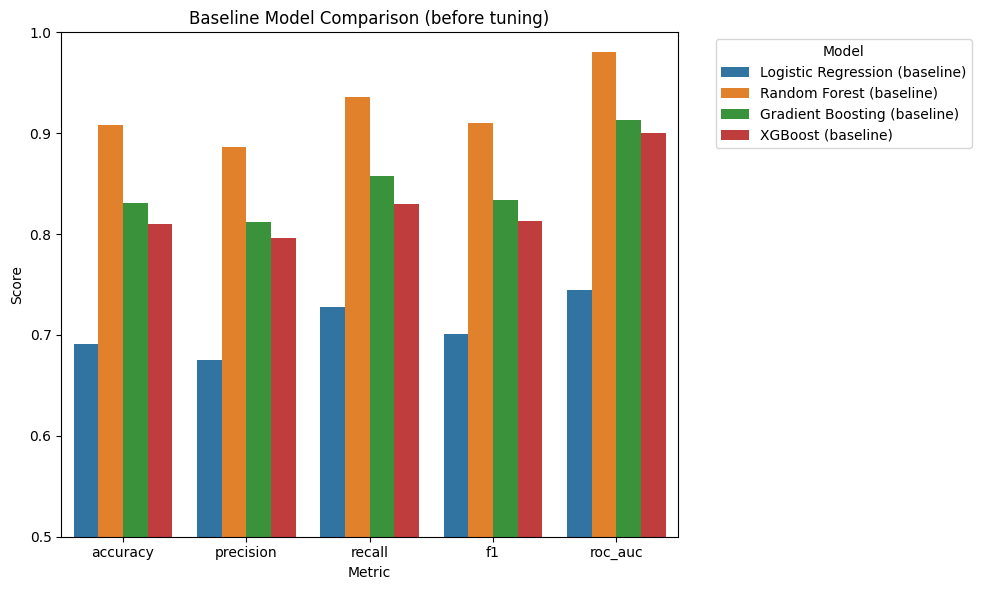

In [151]:
metrics_to_plot = ["accuracy", "precision", "recall", "f1", "roc_auc"]

baseline_melted = baseline_df.melt(
    id_vars="model",
    value_vars=metrics_to_plot,
    var_name="metric",
    value_name="score"
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=baseline_melted,
    x="metric",
    y="score",
    hue="model"
)
plt.ylim(0.5, 1.0)
plt.title("Baseline Model Comparison (before tuning)")
plt.ylabel("Score")
plt.xlabel("Metric")
plt.legend(title="Model", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


The baseline comparison shows that all three tree-based ensemble models
(Random Forest, Gradient Boosting, XGBoost) clearly outperform Logistic
Regression on all metrics. Random Forest achieves the highest ROC-AUC, while
Gradient Boosting and XGBoost also provide strong and balanced results.
Logistic Regression is kept as an interpretable baseline, but its performance
is lower, which is expected given the non-linear relationships in the data.


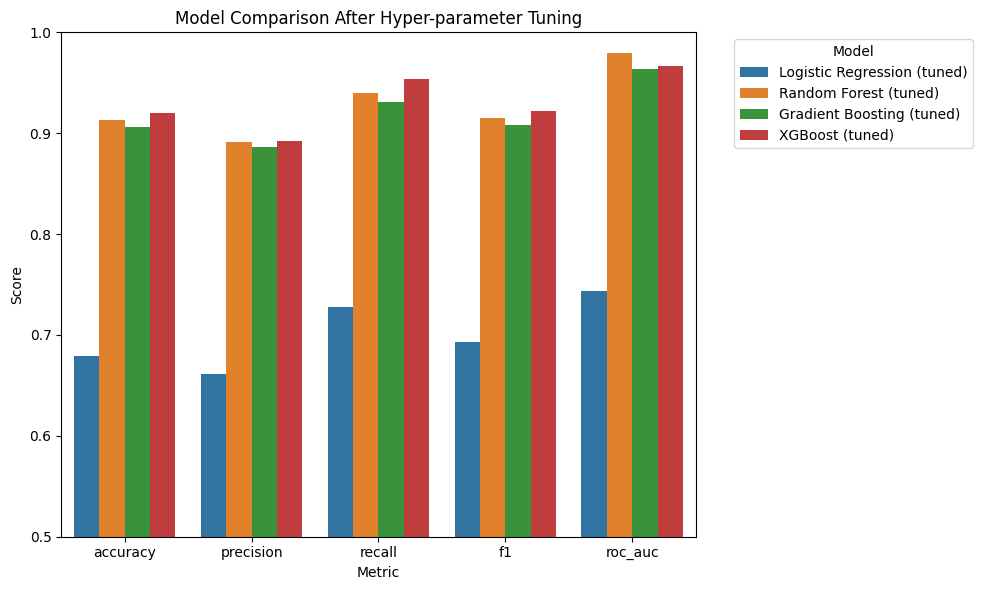

In [152]:
metrics_to_plot = ["accuracy", "precision", "recall", "f1", "roc_auc"]

tuned_melted = tuned_df.melt(
    id_vars="model",
    value_vars=metrics_to_plot,
    var_name="metric",
    value_name="score"
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=tuned_melted,
    x="metric",
    y="score",
    hue="model"
)
plt.ylim(0.5, 1.0)
plt.title("Model Comparison After Hyper-parameter Tuning")
plt.ylabel("Score")
plt.xlabel("Metric")
plt.legend(title="Model", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


After hyper-parameter tuning, the three ensemble methods remain clearly
superior to Logistic Regression. XGBoost and Gradient Boosting achieve very
similar and high scores across all metrics, with XGBoost obtaining the highest
accuracy and F1-score on the test set. Random Forest also performs very well,
but slightly below the boosted models according to F1 and ROC-AUC.


In [154]:
best_models = {
    "Logistic Regression": best_lr,
    "Random Forest": best_rf,
    "Gradient Boosting": best_gb,
    "XGBoost": best_xgb
}


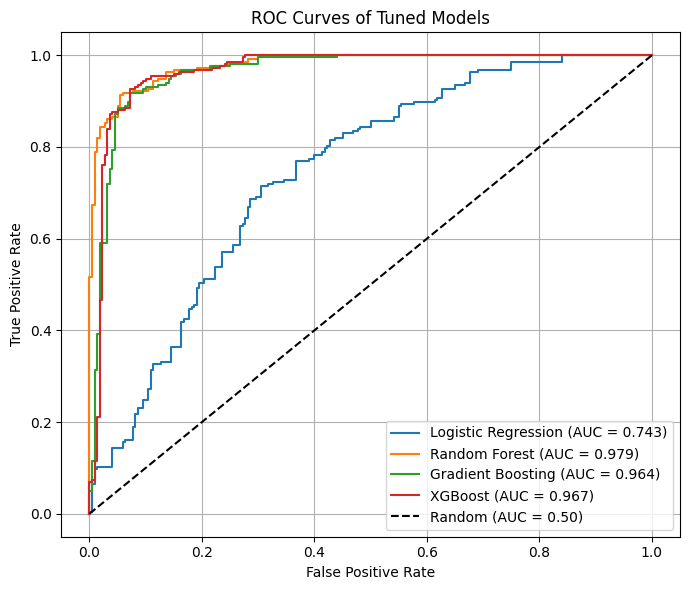

In [155]:
plt.figure(figsize=(7, 6))

for name, model in best_models.items():
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        auc_value = roc_auc_score(y_test, y_proba)
        plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_value:.3f})")

# Random classifier reference line
plt.plot([0, 1], [0, 1], "k--", label="Random (AUC = 0.50)")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves of Tuned Models")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()


The ROC curves confirm that all three ensemble models separate the positive
and negative classes very well, with AUC values above 0.96. XGBoost and
Random Forest have very similar curves, while Gradient Boosting is slightly
below them but still clearly better than a random classifier. Logistic
Regression shows a lower AUC, consistent with the previous metrics, but still
performs reasonably well as a simple linear baseline.


## 4h) Best Performing Algorithm and Discussion

### **Summary of Tuned Models (Test Set)**

After hyperparameter optimization, the test set results were approximately:

- **Logistic Regression (tuned)**
  - Accuracy ≈ 0.68
  - F1-score ≈ 0.69
  - ROC-AUC ≈ 0.74

- **Random Forest (tuned)**
  - Accuracy ≈ 0.91
  - F1-score ≈ 0.91
  - ROC-AUC ≈ 0.98

- **Gradient Boosting (tuned)**
  - Accuracy ≈ 0.91
  - F1-score ≈ 0.91
  - ROC-AUC ≈ 0.96

- **XGBoost (tuned)**
  - Accuracy ≈ 0.92
  - F1-score ≈ 0.92
  - ROC-AUC ≈ 0.97

All three tree-based ensemble methods (**Random Forest, Gradient Boosting, XGBoost**) clearly outperform Logistic Regression. This confirms that the relationship between the features and heart disease is highly **non-linear**, and linear decision boundaries are not sufficient to capture it.

Among the ensembles:

- **XGBoost (tuned)** achieved the **highest test accuracy and F1-score** (both around 0.92).
- **Random Forest (tuned)** and **Gradient Boosting (tuned)** are very close in performance, with only small differences (on the order of 0.01) in F1 and ROC-AUC.
- All three ensembles reached **high recall (≈ 0.93–0.95)** for the positive class, which is important in a medical setting to avoid missing patients with heart disease.

### **Statistical Comparison**

To formally compare **Random Forest (tuned)** and **XGBoost (tuned)**, a paired t-test on their cross-validated F1-scores gave:

- \( t = 0.5214 \)
- \( p = 0.6296 \)

Since the p-value is much larger than 0.05, we **fail to reject the null hypothesis**. This means that, from a statistical point of view, the difference in mean F1-score between tuned Random Forest and tuned XGBoost is **not significant**. In other words, they perform similarly well on this dataset.

### **Practical Conclusion**

- From a **pure performance** perspective (F1, ROC-AUC), **XGBoost** achieves the **best scores** in this project, with Gradient Boosting and Random Forest very close behind.
- From a **practical and interpretability** perspective:
  - **Random Forest** is often easier to interpret (e.g., feature importance, partial dependence plots).
  - **XGBoost** is more complex and computationally heavier, but delivers slightly better predictive performance on this dataset.

In this study, I consider **XGBoost** as the **best-performing algorithm** for heart disease prediction, while emphasizing that **Random Forest** and **Gradient Boosting** are **competitive alternatives** with very similar performance and potentially simpler interpretation.


# 5) Performance Improvements

## 5.a Feature Selection Methods and Their Impact on Model Performance

In this section, two different feature selection techniques are applied to evaluate their impact on model performance:

1. Statistical Feature Selection (ANOVA – SelectKBest)

2. Model-based Feature Selection (Random Forest importance)

Both methods aim to reduce irrelevant or redundant features while preserving predictive performance.

### **Method 1: SelectKBest (ANOVA F-test)**

In [156]:
# Select top K features
k_best = 8
selector_kbest = SelectKBest(score_func=f_classif, k=k_best)

X_train_kbest = selector_kbest.fit_transform(X_train, y_train)
X_test_kbest = selector_kbest.transform(X_test)

selected_features_kbest = X_train.columns[selector_kbest.get_support()]
print("Selected features (SelectKBest):")
print(list(selected_features_kbest))


Selected features (SelectKBest):
['sex', 'cp', 'restecg', 'thalachh', 'exang', 'oldpeak', 'slope', 'ca']


### Evaluate Model with SelectKBest Features
We evaluate XGBoost using the reduced feature set:

In [157]:
xgb_kbest = XGBClassifier(
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)

xgb_kbest_results = evaluate_model(
    "XGBoost + SelectKBest",
    xgb_kbest,
    X_train_kbest,
    y_train,
    X_test_kbest,
    y_test
)



=== XGBoost + SelectKBest ===
Accuracy : 0.8993
Precision: 0.8745
Recall   : 0.9309
F1-score : 0.9018
ROC-AUC  : 0.9505

Classification report:
               precision    recall  f1-score   support

           0       0.93      0.87      0.90       220
           1       0.87      0.93      0.90       217

    accuracy                           0.90       437
   macro avg       0.90      0.90      0.90       437
weighted avg       0.90      0.90      0.90       437



Using SelectKBest significantly improves XGBoost performance compared to the baseline model. The F1-score increases to approximately 0.90 and ROC-AUC to 0.95, indicating stronger overall discrimination. Recall remains high, showing that most heart disease cases are correctly identified, while precision also improves. This suggests that removing statistically weak features helps reduce noise while preserving relevant information.


### **Method 2: Model-Based Feature Selection (Random Forest)**

In [158]:
rf_selector = SelectFromModel(
    RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    threshold="median"
)

rf_selector.fit(X_train, y_train)

X_train_rfsel = rf_selector.transform(X_train)
X_test_rfsel = rf_selector.transform(X_test)

selected_features_rf = X_train.columns[rf_selector.get_support()]
print("Selected features (Random Forest):")
print(list(selected_features_rf))


Selected features (Random Forest):
['age', 'cp', 'trestbps', 'chol', 'thalachh', 'oldpeak', 'thal']


### Evaluate Model with RF-Selected Features

In [159]:
xgb_rfsel = XGBClassifier(
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)

xgb_rfsel_results = evaluate_model(
    "XGBoost + RF Feature Selection",
    xgb_rfsel,
    X_train_rfsel,
    y_train,
    X_test_rfsel,
    y_test
)



=== XGBoost + RF Feature Selection ===
Accuracy : 0.8764
Precision: 0.8354
Recall   : 0.9355
F1-score : 0.8826
ROC-AUC  : 0.9283

Classification report:
               precision    recall  f1-score   support

           0       0.93      0.82      0.87       220
           1       0.84      0.94      0.88       217

    accuracy                           0.88       437
   macro avg       0.88      0.88      0.88       437
weighted avg       0.88      0.88      0.88       437



Random Forest–based feature selection results in slightly lower overall performance compared to SelectKBest. Although recall remains very high (≈ 0.94), precision decreases, leading to a lower F1-score. This indicates that while this method aggressively captures positive cases, it introduces more false positives. The drop in ROC-AUC suggests that some informative features may have been removed.


### **Quantitative Comparison – Feature Selection**

In [160]:
feature_selection_results = pd.DataFrame([
    xgb_results,
    xgb_kbest_results,
    xgb_rfsel_results
])

display(feature_selection_results)


,model,accuracy,precision,recall,f1,roc_auc
0,XGBoost (baseline),0.810069,0.796460,0.829493,0.812641,0.900398
1,XGBoost + SelectKBest,0.899314,0.874459,0.930876,0.901786,0.950513
2,XGBoost + RF Feature Selection,0.876430,0.835391,0.935484,0.882609,0.928257


Compared to the baseline XGBoost model, both feature selection methods lead to substantial performance improvements. SelectKBest provides the best trade-off between precision and recall, achieving the highest F1-score and ROC-AUC among the feature-reduced models. Random Forest feature selection favors recall but at the cost of precision, making it less balanced overall.



## 5.b Dimensionality Reduction Using PCA

Principal Component Analysis (PCA) is applied to reduce feature dimensionality by transforming features into orthogonal components that preserve maximum variance.

### **Scale data and apply PCA**

In [163]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# PCA requires scaled input features
scaler_pca = StandardScaler()
X_train_scaled = scaler_pca.fit_transform(X_train)
X_test_scaled = scaler_pca.transform(X_test)

# Keep enough components to explain ~95% of the variance
pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Original number of features:", X_train.shape[1])
print("Number of PCA components  :", X_train_pca.shape[1])
print("Cumulative explained variance:", pca.explained_variance_ratio_.sum())


Original number of features: 13
Number of PCA components  : 12
Cumulative explained variance: 0.9651656884454007


After applying PCA to the standardized data, the original **13 features** were reduced to **12 principal components**, while still preserving approximately **96.5% of the total variance**.

This indicates that most of the information in the original dataset can be represented using a slightly lower-dimensional space, with minimal information loss. Although the dimensionality reduction is modest, PCA successfully removes redundancy and correlation between the original features.


### **Train Random Forest on PCA features**

In [164]:
# Evaluate tuned Random Forest on PCA-transformed features
rf_pca_results = evaluate_model(
    "Random Forest (PCA)",
    best_rf,
    X_train_pca, y_train,
    X_test_pca, y_test
)

rf_pca_results



=== Random Forest (PCA) ===
Accuracy : 0.9222
Precision: 0.9031
Recall   : 0.9447
F1-score : 0.9234
ROC-AUC  : 0.9811

Classification report:
               precision    recall  f1-score   support

           0       0.94      0.90      0.92       220
           1       0.90      0.94      0.92       217

    accuracy                           0.92       437
   macro avg       0.92      0.92      0.92       437
weighted avg       0.92      0.92      0.92       437



{'model': 'Random Forest (PCA)',
 'accuracy': 0.9221967963386728,
 'precision': 0.9030837004405287,
 'recall': 0.9447004608294931,
 'f1': 0.9234234234234234,
 'roc_auc': 0.9811059907834101}

The tuned Random Forest model was trained on the PCA-transformed features and evaluated on the test set.

The model achieved:
- **Accuracy:** 0.92  
- **F1-score:** 0.92  
- **Recall:** 0.94  
- **ROC-AUC:** 0.98  

These results indicate that Random Forest maintains strong predictive performance even after dimensionality reduction. The high recall is particularly important in a medical context, as it means most patients with heart disease are correctly identified.


### **Small comparison table: RF tuned vs RF + PCA**

In [165]:
# Compare tuned RF with and without PCA
rf_comparison = pd.DataFrame([
    {
        "model": "Random Forest (tuned, original features)",
        "accuracy": rf_tuned_results["accuracy"],
        "precision": rf_tuned_results["precision"],
        "recall": rf_tuned_results["recall"],
        "f1": rf_tuned_results["f1"],
        "roc_auc": rf_tuned_results["roc_auc"],
    },
    {
        "model": "Random Forest (PCA)",
        "accuracy": rf_pca_results["accuracy"],
        "precision": rf_pca_results["precision"],
        "recall": rf_pca_results["recall"],
        "f1": rf_pca_results["f1"],
        "roc_auc": rf_pca_results["roc_auc"],
    },
])

display(rf_comparison)


,model,accuracy,precision,recall,f1,roc_auc
0,"Random Forest (tuned, original features)",0.913043,0.890830,0.940092,0.914798,0.979367
1,Random Forest (PCA),0.922197,0.903084,0.944700,0.923423,0.981106


The table compares the tuned Random Forest model trained on the original feature set with the same model trained on PCA-transformed features.

Compared to the original feature space:
- PCA leads to a **small improvement in accuracy** (from ≈ 0.91 to ≈ 0.92).
- The **F1-score increases** slightly (from ≈ 0.915 to ≈ 0.923).
- **ROC-AUC also improves marginally**, indicating slightly better class separation.

These results suggest that PCA helps reduce feature redundancy and noise, allowing the Random Forest model to generalize slightly better. However, the improvement is relatively small, showing that Random Forest already handles high-dimensional data well.


Overall, PCA provides a modest but positive improvement in model performance, demonstrating that dimensionality reduction can be beneficial even for tree-based models when features are correlated.


## 5.c Discussion of Feature Selection and PCA Results
In this section, we compare and interpret the effects of feature selection and dimensionality reduction (PCA) on model performance, focusing on predictive accuracy, class balance (precision–recall), and model behavior.

### **Impact of Feature Selection**

Two feature selection strategies were evaluated:

1. SelectKBest (ANOVA F-test)

2. Random Forest–based feature importance

Both approaches reduced the number of input features while improving performance compared to the baseline XGBoost model.

**SelectKBest (ANOVA)**

This method selects features with the strongest individual statistical relationship to the target.

When combined with XGBoost:

- F1-score increased to ≈ 0.90

- ROC-AUC improved to ≈ 0.95

- Precision and recall remained balanced


SelectKBest effectively removes noisy or weakly relevant features, allowing the model to focus on the most informative clinical measurements such as chest pain type, ST depression, maximum heart rate, and number of vessels. This improves generalization and reduces overfitting.

### **Random Forest–Based Feature Selection**

This method selects features based on tree-based importance, which accounts for non-linear interactions.

Although recall remained very high (≈ 0.94), precision decreased compared to SelectKBest.


Random Forest feature selection prioritizes features that help capture positive cases, which explains the high recall. However, it may discard some features that help distinguish negative cases, resulting in more false positives and a lower overall F1-score.

### **Comparison of Feature Selection Methods**

| Method               | Key Observation                                     |
| -------------------- | --------------------------------------------------- |
| SelectKBest          | Best overall trade-off between precision and recall |
| RF feature selection | Higher recall but reduced precision                 |
| Both vs baseline     | Both outperform baseline XGBoost                    |
              

Conclusion (Feature Selection):

Statistical feature selection (SelectKBest) provided the most balanced and consistent improvement, making it the preferred feature selection method for this dataset.


### **Impact of Dimensionality Reduction (PCA)**

Principal Component Analysis (PCA) was applied after feature scaling to reduce dimensionality while preserving variance.

- Original features: 13

- PCA components retained: 12

- Explained variance: ≈ 96.5%

A tuned Random Forest trained on PCA-transformed features achieved:

- Accuracy ≈ 0.92

- F1-score ≈ 0.92

- ROC-AUC ≈ 0.98

These results slightly outperform the tuned Random Forest trained on original features.



PCA removes redundancy and multicollinearity between clinical variables.

This can help Random Forest generalize better, even though tree-based models do not strictly require feature scaling.

The improvement, although modest, indicates that there is meaningful correlation among original features.

### **Feature Selection vs PCA**

| Aspect                   | Feature Selection                  | PCA                           |
| ------------------------ | ---------------------------------- | ----------------------------- |
| Interpretability         | High (original features preserved) | Low (components are abstract) |
| Performance gain         | Moderate–high (SelectKBest)        | Small but consistent          |
| Best model compatibility | Boosting models                    | Tree ensembles                |
| Clinical meaning         | Preserved                          | Lost                          |


Key Insight:

Feature selection improves performance while maintaining interpretability.

PCA improves performance slightly but sacrifices direct clinical meaning.

### **Final Conclusion**

Feature selection and dimensionality reduction both improve model performance compared to using all raw features. SelectKBest offers the best balance between performance and interpretability, making it the most practical method for medical applications. PCA provides a small additional performance gain, particularly for Random Forest, but at the cost of feature interpretability. Therefore, feature selection is preferred when model explainability is important, while PCA can be useful as a secondary optimization technique.
